In [2]:
import json

def load_result_file(filepath):
    """Load and validate a result JSON file."""
    with open(filepath, "r") as f:
        try:
            data = json.load(f)
        except Exception as e:
            raise ValueError(f"Failed to parse JSON: {e}")

    # Basic structural validation
    if not isinstance(data, list):
        raise ValueError("Expected list of records")

    required_keys = {
        "concurrency", "avg_exec_time", "avg_entry_total_time",
        "offload_count", "avg_cpu_usage", "avg_mem_usage_MB"
    }

    for i, entry in enumerate(data):
        if not isinstance(entry, dict):
            raise ValueError(f"Item {i} is not a dict")
        missing = required_keys - entry.keys()
        if missing:
            raise ValueError(f"Missing keys in item {i}: {missing}")

    return data


In [3]:
file_path = "tmp data/results_basic_federated.json"
results_basic_federated = load_result_file(file_path)

# 预览前几项
results_basic_federated[:3]

[{'fn_type': 'basic',
  'concurrency': 1,
  'avg_exec_time': 0.04898733615875244,
  'max_exec_time': 0.09939217567443848,
  'min_exec_time': 0.04558110237121582,
  'avg_entry_total_time': 0.6076272349999999,
  'max_entry_time': 0.745728,
  'min_entry_time': 0.524622,
  'offload_count': 0,
  'total_offload_count': 0,
  'avg_cpu_usage': 98.85112750515127,
  'avg_mem_usage_MB': 1027.3533854166667,
  'total_cpu_usage': 593.1067650309076,
  'total_mem_usage_MB': 6164.1203125,
  'samples': 200},
 {'fn_type': 'basic',
  'concurrency': 2,
  'avg_exec_time': 0.06134386360645294,
  'max_exec_time': 0.13491034507751465,
  'min_exec_time': 0.04532432556152344,
  'avg_entry_total_time': 0.6243510225000004,
  'max_entry_time': 0.824516,
  'min_entry_time': 0.492887,
  'offload_count': 0,
  'total_offload_count': 0,
  'avg_cpu_usage': 109.11420813582286,
  'avg_mem_usage_MB': 1034.4596354166665,
  'total_cpu_usage': 654.6852488149372,
  'total_mem_usage_MB': 6206.757812499999,
  'samples': 400},
 {'f

In [4]:
import os

# 你可以根据实际路径调整文件名
file_paths = {
    "basic_centralized": "tmp data/results_basic_centralized.json",
    "basic_decentralized": "tmp data/results_basic_decentralized.json",
    "basic_federated": "tmp data/results_basic_federated.json",
    "data_local_centralized": "tmp data/results_data_local_centralized.json",
    "data_local_decentralized": "tmp data/results_data_local_decentralized.json",
    "data_local_federated": "tmp data/results_data_local_federated.json",
}

# 批量加载
loaded_data = {}
for key, path in file_paths.items():
    try:
        loaded_data[key] = load_result_file(path)
    except Exception as e:
        print(f"[ERROR] Failed to load {key}: {e}")


In [6]:
def extract_plot_data(dataset):
    return {
        "concurrency": [entry["concurrency"] for entry in dataset],
        "avg_exec_time": [entry["avg_exec_time"] for entry in dataset],
        "avg_entry_time": [entry["avg_entry_total_time"] for entry in dataset],
        "offload_count": [entry["offload_count"] for entry in dataset],
        "cpu": [entry["avg_cpu_usage"] for entry in dataset],
        "mem": [entry["avg_mem_usage_MB"] for entry in dataset],
    }

plot_data = {k: extract_plot_data(v) for k, v in loaded_data.items()}


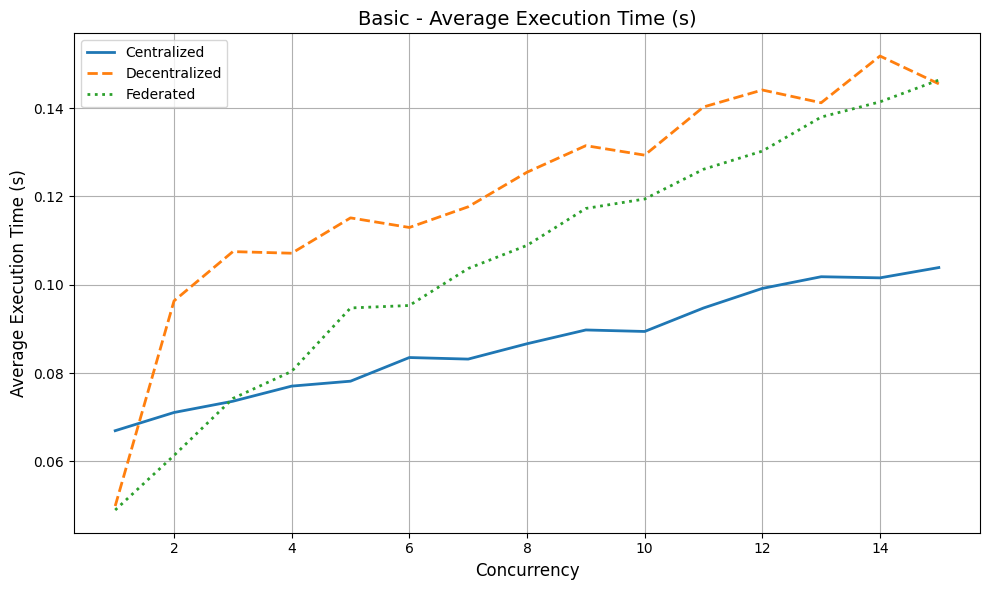

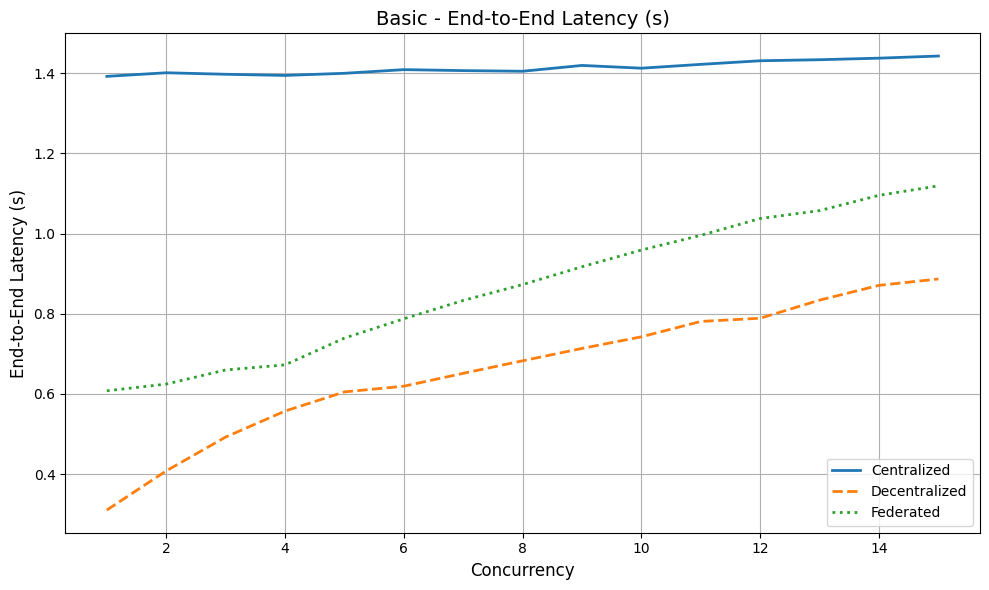

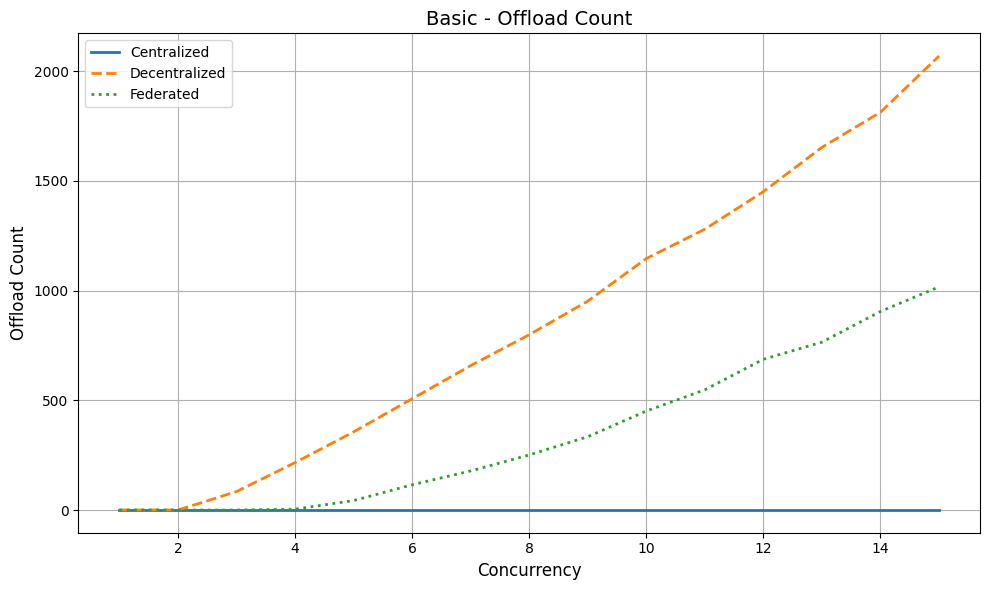

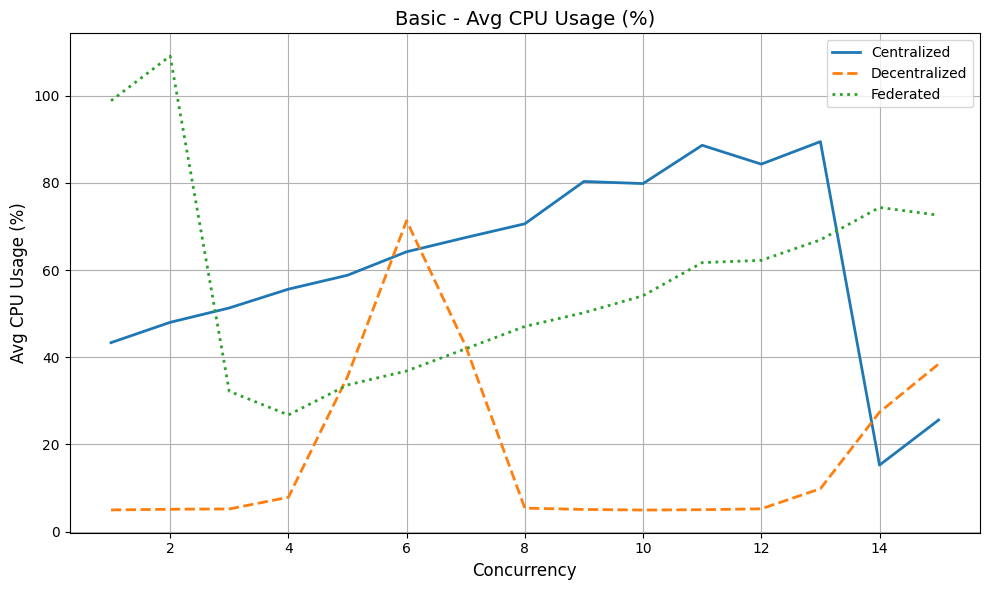

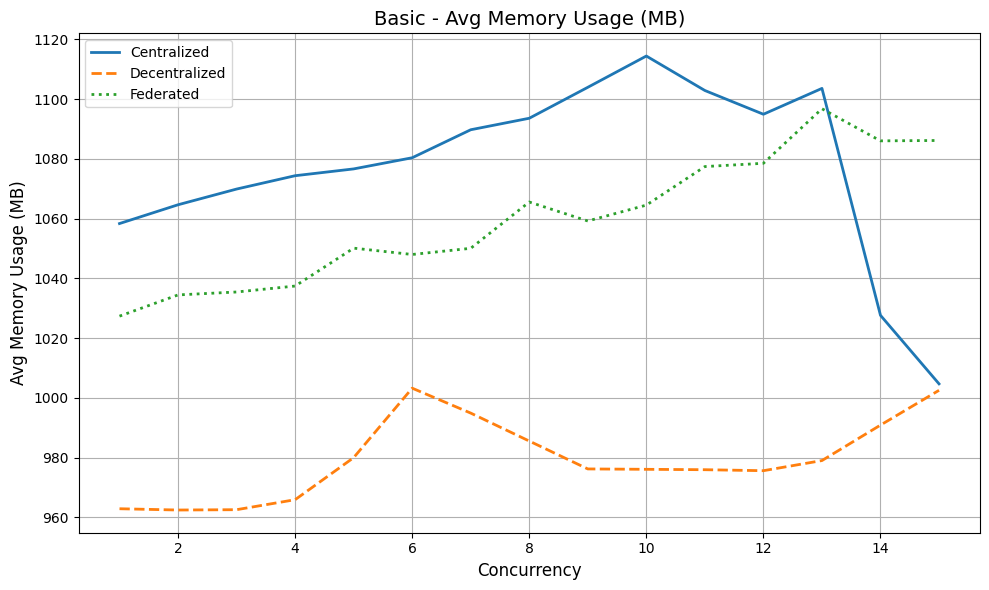

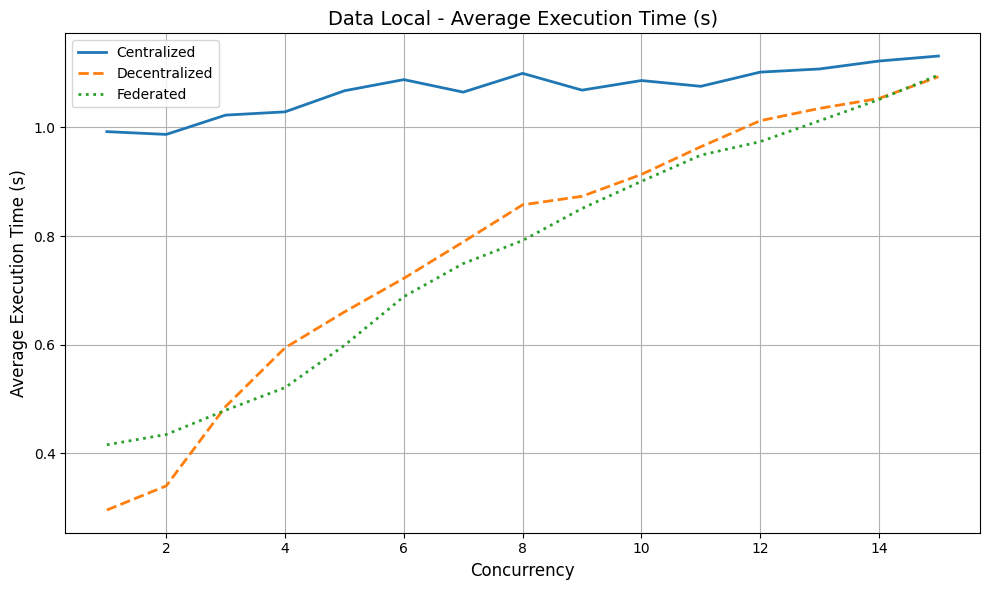

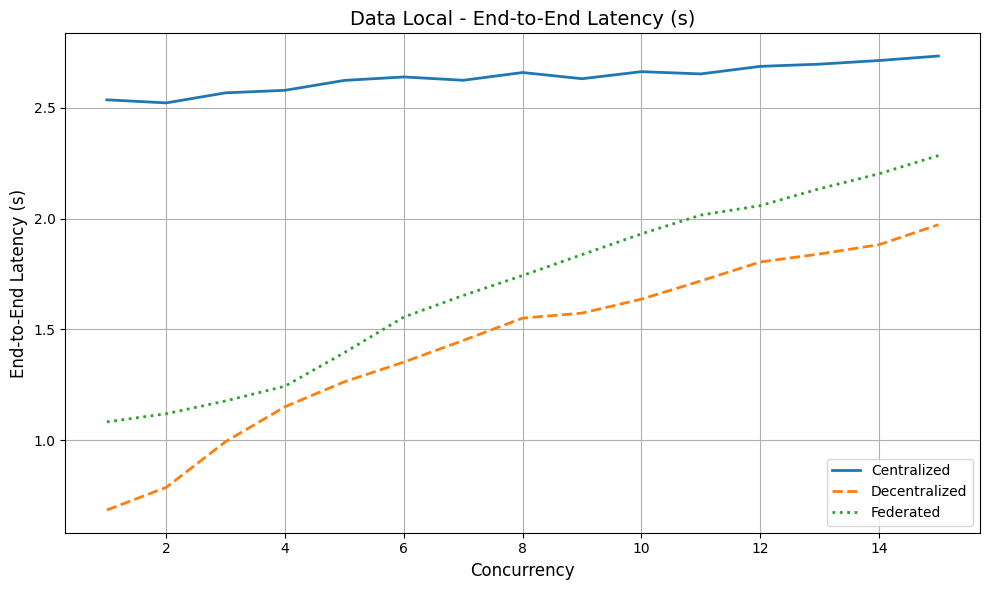

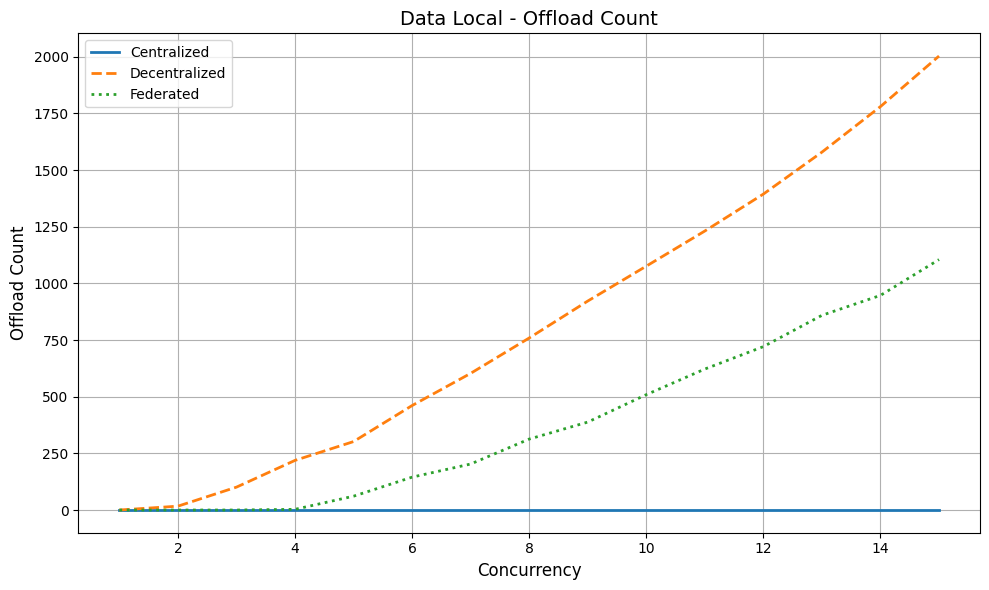

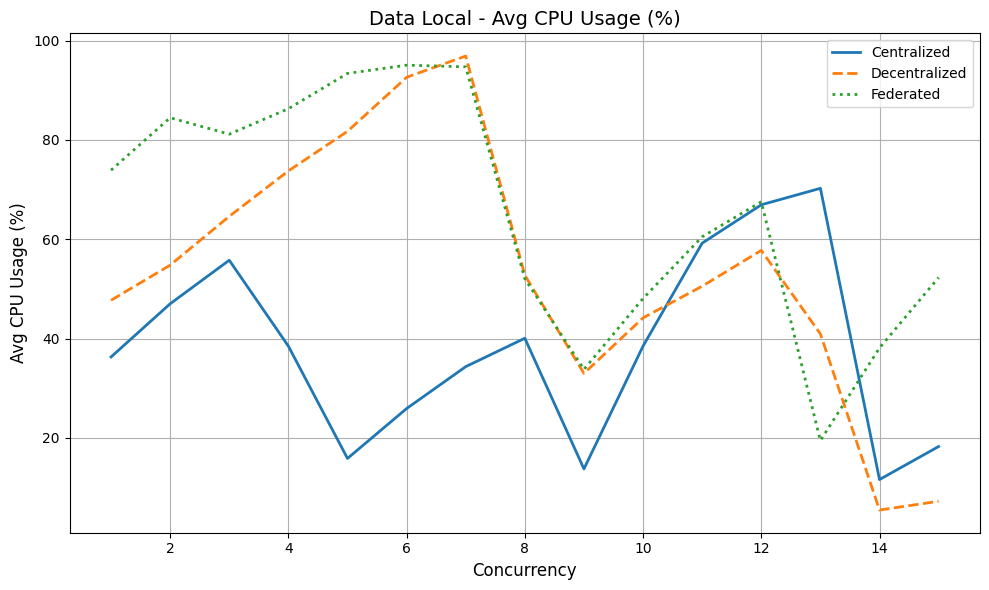

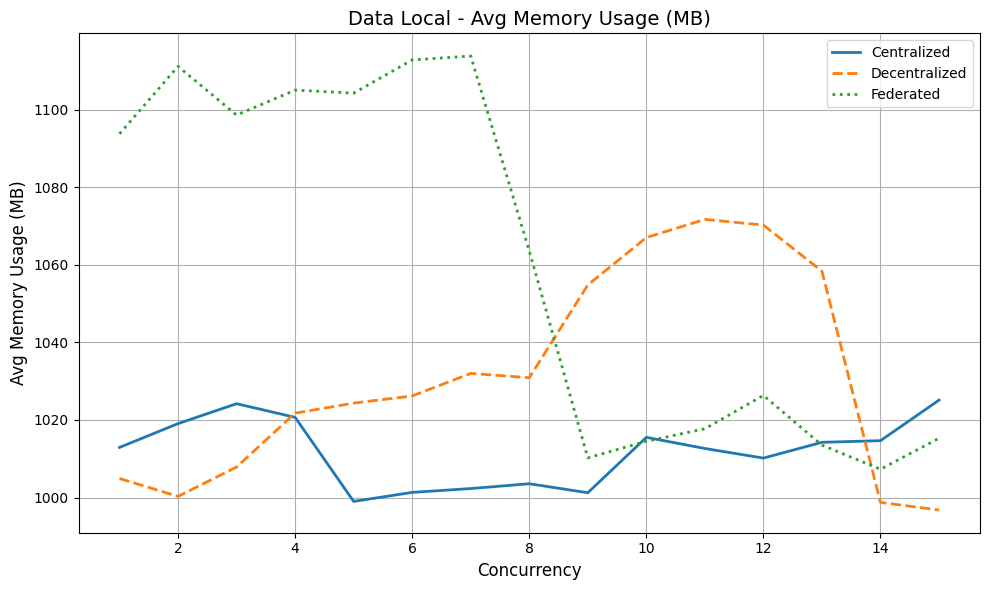

In [8]:
import matplotlib.pyplot as plt

def plot_single_metric(task_type, metric_key, metric_label, plot_data):
    """绘制单个指标图（一个任务类型 + 多种架构）"""
    plt.figure(figsize=(10, 6))
    line_style = {
        "centralized": "solid",
        "decentralized": "dashed",
        "federated": "dotted"
    }

    for arch in ["centralized", "decentralized", "federated"]:
        key = f"{task_type}_{arch}"
        if key in plot_data:
            plt.plot(
                plot_data[key]["concurrency"],
                plot_data[key][metric_key],
                label=arch.title(),
                linestyle=line_style[arch],
                linewidth=2
            )

    plt.title(f"{task_type.replace('_', ' ').title()} - {metric_label}", fontsize=14)
    plt.xlabel("Concurrency", fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 所有指标
metrics_info = {
    "avg_exec_time": "Average Execution Time (s)",
    "avg_entry_time": "End-to-End Latency (s)",
    "offload_count": "Offload Count",
    "cpu": "Avg CPU Usage (%)",
    "mem": "Avg Memory Usage (MB)"
}

# Basic task 单独图
for metric, label in metrics_info.items():
    plot_single_metric("basic", metric, label, plot_data)

# Data-local task 单独图
for metric, label in metrics_info.items():
    plot_single_metric("data_local", metric, label, plot_data)



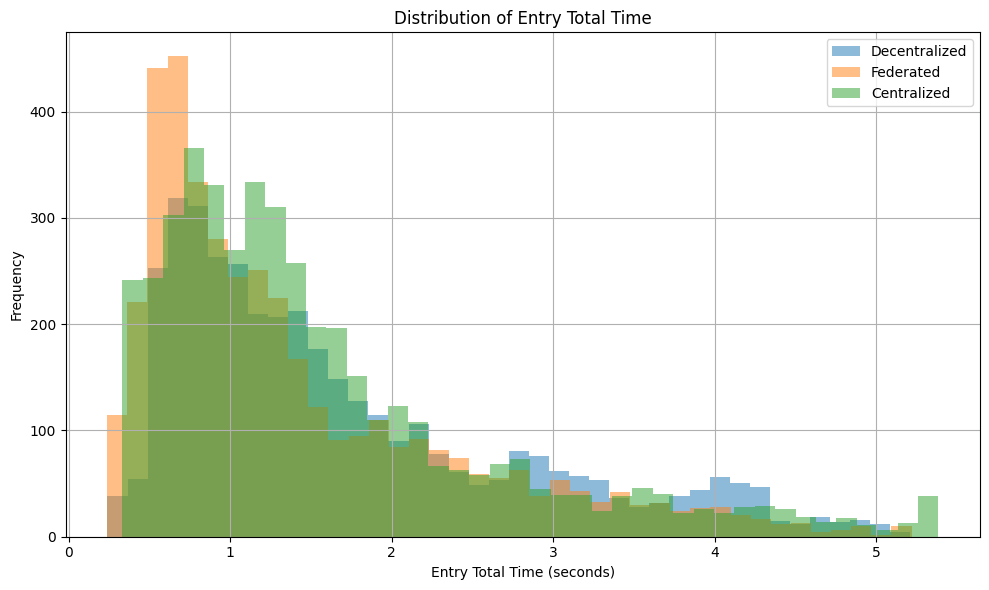

         mode     mean      std      min      max
Decentralized 1.716334 1.097474 0.239680 5.212594
    Federated 1.421774 0.999421 0.238135 5.220306
  Centralized 1.579449 1.072829 0.331807 5.386893


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 重新加载 CSV 文件路径
paths = [
    "results_basic_decentralized.csv",
    "results_basic_federated.csv",
    "results_basic_centralized.csv"
]
labels = ["Decentralized", "Federated", "Centralized"]

dataframes = [pd.read_csv(p) for p in paths]

stats_summary = []

plt.figure(figsize=(10, 6))
for df, label in zip(dataframes, labels):
    total_times = df["total_time"].dropna()
    total_times = total_times[(total_times != -1) & total_times.notna()]
    plt.hist(total_times, bins=40, alpha=0.5, label=label)

    stats_summary.append({
        "mode": label,
        "mean": total_times.mean(),
        "std": total_times.std(),
        "min": total_times.min(),
        "max": total_times.max()
    })

plt.title("Distribution of Entry Total Time")
plt.xlabel("Entry Total Time (seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 展示统计汇总
summary_df = pd.DataFrame(stats_summary)

print(summary_df.to_string(index=False))
